In [46]:
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("OPENROUTER_API_KEY")

In [47]:
from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(model="openai/gpt-oss-20b:free", api_key=API_KEY)
llm.invoke("salom sen qanday modelsan")





AIMessage(content='Salom! Men OpenAI tomonidan ishlab chiqilgan **ChatGPT** – bu yirik til modeli bo‘lib, hozirgi vaqtda GPT‑4 arxitekturasi asosida ishlayapman. Men sizga savollaringizga javob berish, ma`lumot izlash yoki har xil mavzularda suhbatlashishda yordam berish uchun tayyorman. Nima bilan yordam kerak?', additional_kwargs={'reasoning_content': 'The user speaks Uzbek: "salom sen qanday modelsan" translates to "hello, what model are you" possibly "what model are you?" The user is likely asking the assistant\'s model identity. The assistant should answer in Uzbek? The user wrote in Uzbek. The assistant should respond in Uzbek: "Men ChatGPT 3.5 yoki 4?" The user says "salom sen qanday modelsan" means "hello, what model are you?" The assistant can answer: "Men ChatGPT, OpenAI tomonidan ishlab chiqilgan umumiy maqsadli til modeli, v3.5 yoki v4 variantida to‘g‘ri bilmasam, sizga yordam berish uchun tayyorman." Should adjust: the current model is gpt-4? OpenAI\'s ChatGPT might be GPT

In [48]:
from typing import Annotated, TypedDict, List
from operator import add
from langchain_core.messages import BaseMessage


class graph_schema(TypedDict):
    user_message: List[BaseMessage]
    all_messages: Annotated[List[BaseMessage], add]



In [49]:
def generate_post(state):
    user_message = state["user_message"]

    ai_message = llm.invoke(user_message)

    return {"all_messages": user_message + [ai_message]}


def new_post(state):
    user_message = state["user_message"]
    ai_message = llm.invoke(user_message)
    return {"all_messages": user_message + [ai_message]}


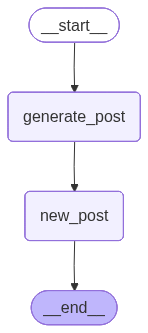

In [50]:
from langgraph.graph import START, END, StateGraph

graph = StateGraph(graph_schema)

graph.add_node("generate_post", generate_post)
graph.add_node("new_post", new_post)

graph.add_edge(START, "generate_post")
graph.add_edge("generate_post", "new_post")
graph.add_edge("new_post", END)

app = graph.compile()

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))



In [51]:
from langchain_core.messages import HumanMessage

natija = app.invoke({
    "user_message": [HumanMessage(content="Salom sen qanday modelsan ?")],
    "all_messages": []
})
natija

{'user_message': [HumanMessage(content='Salom sen qanday modelsan ?', additional_kwargs={}, response_metadata={})],
 'all_messages': [HumanMessage(content='Salom sen qanday modelsan ?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Salom! Men ChatGPT‑ning GPT‑4ఇn texnikasiga asoslangan modeliman. Sizga turli mavzularda savollarga근 javob berish, matn tahriri, tushuntirishlar, yaratish, fikr‑muvaffaqiyat va boshqa ko‘plab vazifalarni bajarishda yordam berishga tayyorman. Sizga qanday sevishman?', additional_kwargs={'reasoning_content': 'The user speaks Uzbek: "Salom sen qanday modelsan?" meaning "Hello, what kind of model are you?" They ask what model they are using. They want an English or Uzbek response. I should respond in Uzbek or bilingual? As the user is Uzbek, respond in Uzbek. They ask what model: I\'m ChatGPT, GPT-4. Should mention context.\n\nLet\'s respond.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user